<a href="https://colab.research.google.com/github/anand193/Book-Price-EDA/blob/main/Fashion_Image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install -q keras tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the datasets
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [8]:
x_train.dtype

dtype('uint8')

In [11]:
x_train[7]

array([[  0,   0,   0,   0,   0,   1,   1,   0,   0,   0,   0,  63,  28,
          0,   0,   0,  33,  85,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   2,   0,   0,  28, 126, 241, 255, 255,
        255, 255, 255, 255, 252, 248, 111,   0,   0,   0,   2,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   2,   0,   0, 206, 244, 251, 241, 230, 238,
        221, 205, 230, 240, 230, 239, 251, 233, 165,   0,   0,   2,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0, 199, 251, 228, 234, 233, 236, 235,
        245, 247, 237, 234, 239, 230, 230, 235, 255, 176,   0,   0,   1,
          0,   0],
       [  0,   0,   0,   0,   0,  81, 254, 226, 228, 239, 237, 236, 234,
        232, 233, 235, 235, 236, 239, 237, 233, 225, 246,  73,   0,   0,
          0,   0],
       [  0,   0,   3,   0,   0, 255, 235, 239, 223, 234, 238, 236, 237,
        236, 235, 235, 235, 235, 236, 235, 234, 230, 231, 255,  24,   0,
          4,   0],
       [  0,   0,   0,   0, 177, 239, 223, 254, 223, 232, 234, 234, 236,
        236, 235, 235, 235, 235, 235, 234, 231, 233, 222, 246,  88,   0,
          1,   0],
       [  0,   0,   0,   0, 234, 239, 229, 255, 220, 232, 233, 232, 234,
        235, 235, 235, 235, 235, 234, 233, 232, 230, 228, 254, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 225, 240, 226, 255, 221, 227, 232, 228, 231,
        230, 228, 229, 231, 230, 228, 228, 232, 223, 229, 244, 231,   0,
          0,   0],
       [  0,   0,   0,  47, 245, 231, 234, 249, 229, 221, 229, 225, 229,
        227, 226, 227, 228, 227, 228, 229, 228, 224, 246, 240, 227,   0,
          0,   0],
       [  0,   0,   0,  51, 248, 230, 245, 246, 230, 226, 230, 227, 230,
        229, 228, 229, 230, 228, 228, 231, 225, 227, 242, 237, 255,   0,
          0,   0],
       [  0,   0,   0, 101, 253, 229, 247, 241, 221, 233, 228, 227, 229,
        228, 227, 228, 230, 227, 230, 234, 225, 229, 251, 229, 243,  55,
          0,   0],
       [  0,   0,   0, 102, 255, 227, 242, 241, 221, 234, 223, 230, 228,
        231, 229, 231, 231, 227, 229, 241, 219, 236, 254, 225, 250, 167,
          0,   0],
       [  0,   0,   0,  90, 255, 229, 236, 231, 222, 236, 223, 231, 229,
        231, 229, 231, 231, 228, 224, 245, 218, 243, 239, 227, 244, 175,
          0,   0],
       [  0,   0,   0, 212, 250, 225, 236, 249, 229, 237, 223, 231, 229,
        231, 229, 231, 231, 230, 221, 243, 225, 248, 230, 236, 234, 255,
          1,   0],
       [  0,   0,   0, 245, 243, 232, 243, 218, 228, 238, 222, 231, 229,
        231, 229, 231, 231, 230, 222, 237, 237, 252, 229, 239, 240, 223,
          0,   0],
       [  0,   0,  27, 255, 235, 242, 237, 216, 230, 236, 224, 229, 227,
        233, 233, 233, 230, 228, 224, 230, 245, 247, 221, 243, 239, 252,
          0,   0],
       [  0,   0,  88, 255, 232, 248, 236, 208, 234, 231, 223, 227, 226,
        233, 232, 232, 230, 228, 224, 224, 235, 233, 234, 247, 235, 255,
          0,   0],
       [  0,   0,  83, 255, 225, 250, 237, 224, 236, 229, 225, 225, 227,
        235, 229, 231, 230, 230, 227, 221, 227, 221, 239, 250, 231, 255,
          0,   0],
       [  0,   0,  20, 255, 224, 248, 234, 226, 232, 222, 225, 224, 231,
        238, 226, 230, 228, 230, 230, 221, 229, 225, 244, 246, 230, 255,
          0,   0],
       [  0,   0,  95, 255, 218, 242, 255, 232, 226, 224, 229, 228, 228,
        232, 228, 229, 231, 233, 232, 226, 221, 224, 247, 244, 228, 255,
          0,   0],
       [  0,   0, 167, 255, 213, 235, 255,  81, 245, 251, 238, 236, 230,
        229, 230, 229, 230, 231, 238, 240, 255, 192, 255, 239, 228, 255,
         23,   0],
       [  0,   0, 173, 242, 224, 233, 255,   0, 136, 226, 239, 255, 229,
        236, 236, 234, 233, 228, 251, 248, 200,  81, 255, 237, 225, 255,
        101,   0],
       [  0,   0, 172, 255, 226, 233, 255,   0,   0,   0,   0,   0,   8,
         21,  22,  21,  20,  14,   0,   0,   0,   0, 255, 238, 229, 246,
        178,   0],
       [  0,   0,  16, 255, 236, 238, 25

In [12]:
#the data is 60000 images of pixel size 28X28
#min and max value in pixel
print('Min Pixel Value:',x_train.min())
print('Max Pixel Value:',x_train.max())

Min Pixel Value: 0
Max Pixel Value: 255


In [16]:
# unique labels we have
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [17]:
class_names = ['T-Shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']

In [18]:
class_names[4]

'Coat'

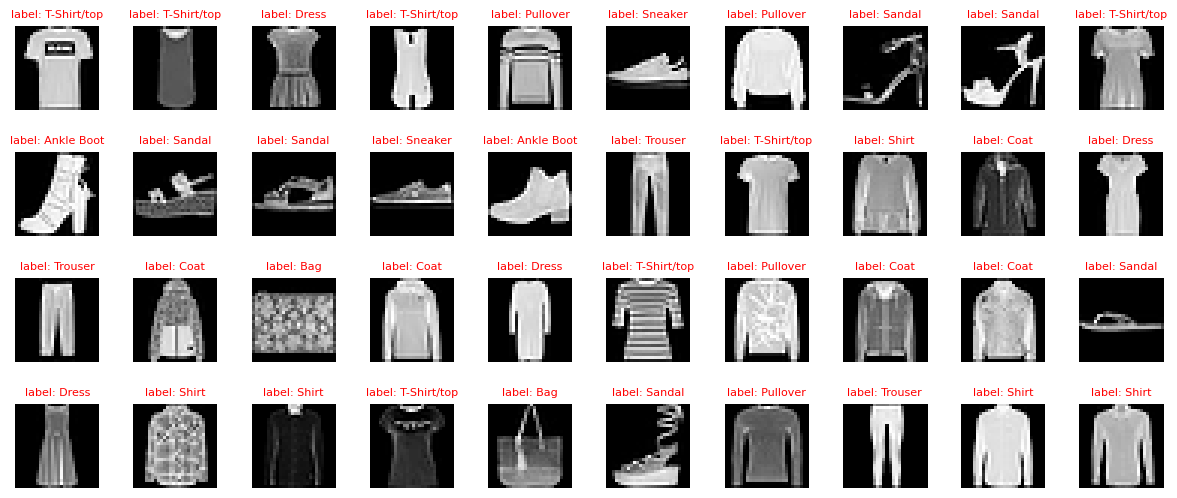

In [27]:
#lets get some images along with their labesl
nrows = 4
ncols = 10
t = 1
plt.figure(figsize=(15,6))
for i in range(1,nrows*ncols+1):
  plt.subplot(nrows,ncols,i)
  plt.imshow(x_train[i],cmap='gray',interpolation = 'nearest')
  plt.title(f'label: {class_names[y_train[i]]}',color = 'red',fontsize=8)
  t += 1
  plt.subplots_adjust(hspace=0.5)
  plt.axis('off')

In [28]:
#imgae is a 3d data we need to make it 2d
#normalization the pixels and reshaping the image
#normalization 0-255 --> 0-1
#reshaping 60000X28X28 --- 60000X784

#lets normalize pixesl
x_train = x_train/255
x_test = x_test/255


In [32]:
#lets reshape the daya
x_train_s = x_train.reshape(60000,28*28)
x_test_s = x_test.reshape(10000,28*28)


In [33]:
x_train_s.shape

(60000, 784)

In [34]:
x_test_s.shape

(10000, 784)

In [35]:
#build a Neural Network model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [37]:
#create a sequential model
model = Sequential()

#add input layer and first hidden layer in model

model.add(Dense(128,activation='relu',input_shape=(784,)))

In [38]:
# lets add another layer

model.add(Dense(64,activation='relu'))

#lets add the output layer

model.add(Dense(10,activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
784*128+128

100480

In [40]:
128*64+64

8256

In [41]:
# we need to compile the model

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [42]:
model.fit(x_train_s,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7670 - loss: 0.6713 - val_accuracy: 0.8543 - val_loss: 0.4088
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8559 - loss: 0.3939 - val_accuracy: 0.8601 - val_loss: 0.3859
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8727 - loss: 0.3464 - val_accuracy: 0.8723 - val_loss: 0.3516
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8871 - loss: 0.3089 - val_accuracy: 0.8765 - val_loss: 0.3375
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8880 - loss: 0.2982 - val_accuracy: 0.8800 - val_loss: 0.3305
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8951 - loss: 0.2794 - val_accuracy: 0.8739 - val_loss: 0.3463
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9004 - loss: 0.2636 - val_accuracy: 0.8829 - val_loss: 0.3253
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9057 - loss: 0.2541

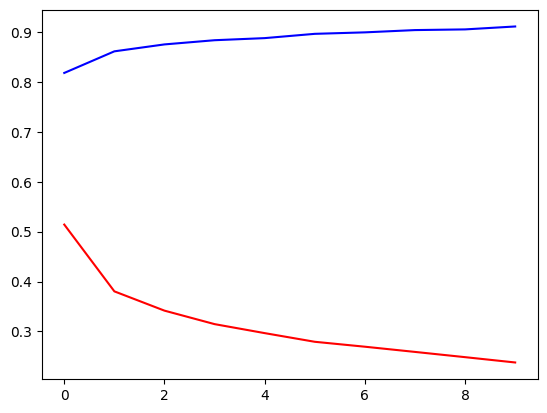

In [44]:
plt.plot(model.history.history['accuracy'],color = 'blue')
plt.plot(model.history.history['loss'],color = 'red')

In [45]:
# lets evaluate this model on test data

loss,acc = model.evaluate(x_test_s,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8822 - loss: 0.3370


In [46]:
print('Accuracy',acc)
print('Loss',loss)

Accuracy 0.8826000094413757
Loss 0.3359271287918091


In [47]:
# let gets the predictions
prediction = model.predict(x_test_s)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [50]:
pred_label = np.argmax(prediction,axis=1)

In [51]:
pred_label

array([9, 2, 1, ..., 8, 1, 5])

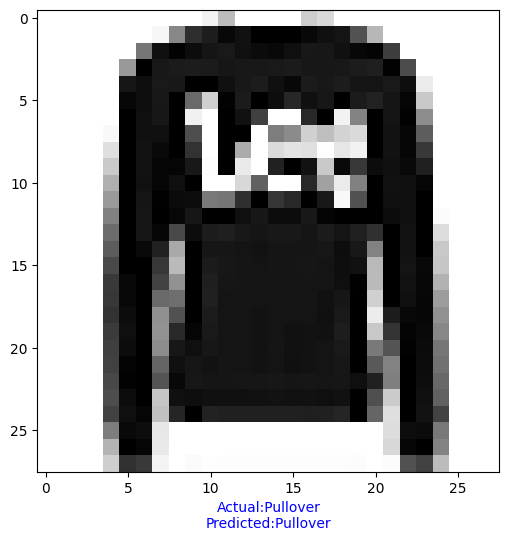

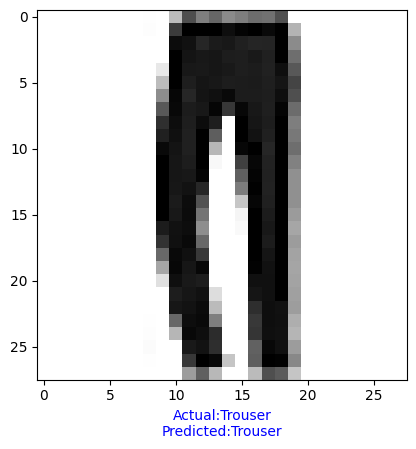

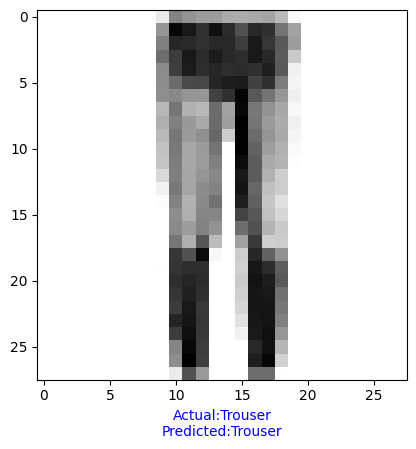

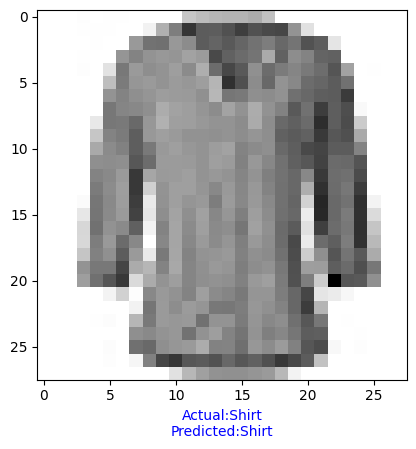

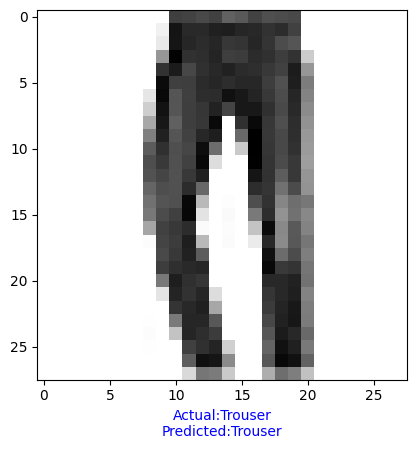

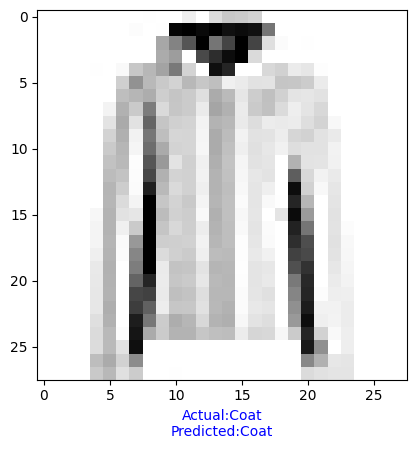

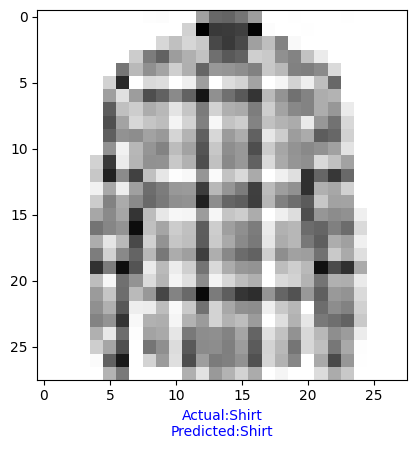

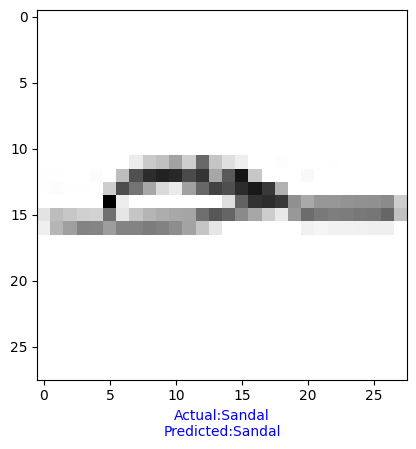

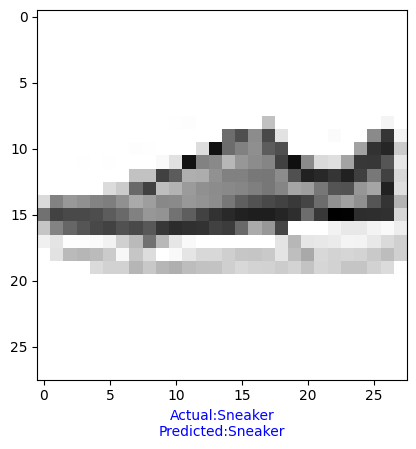

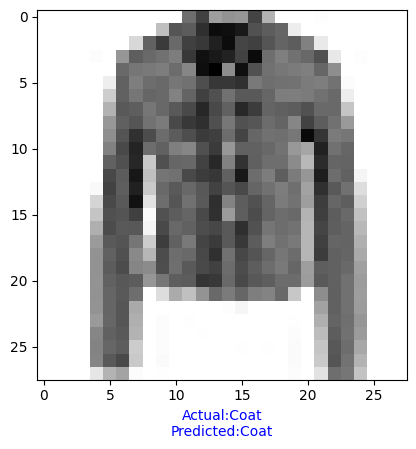

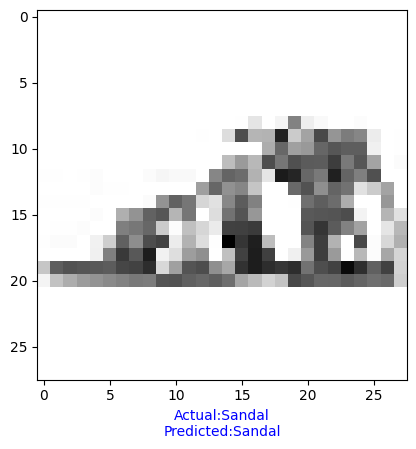

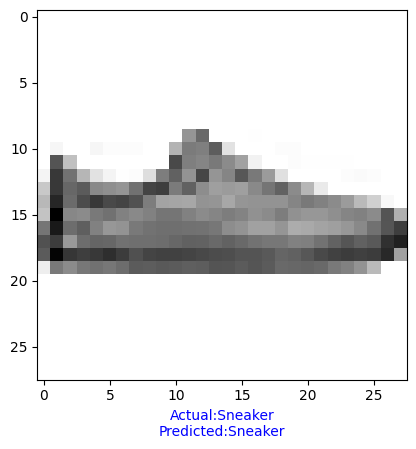

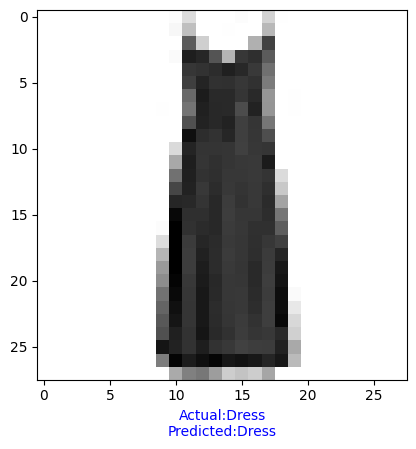

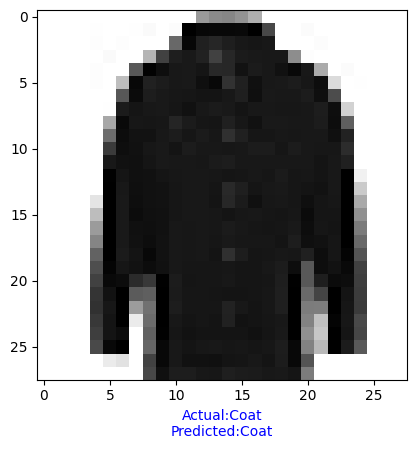

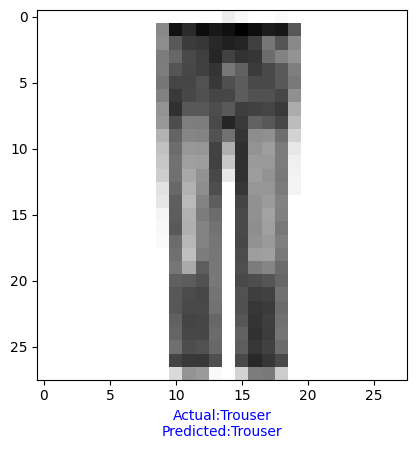

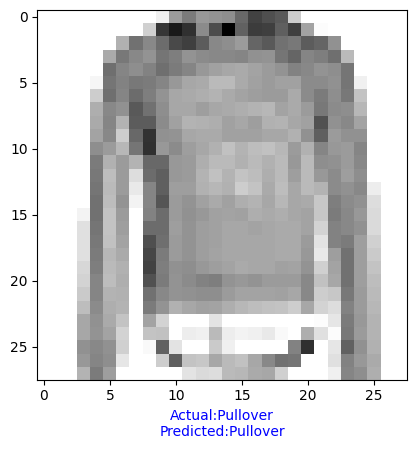

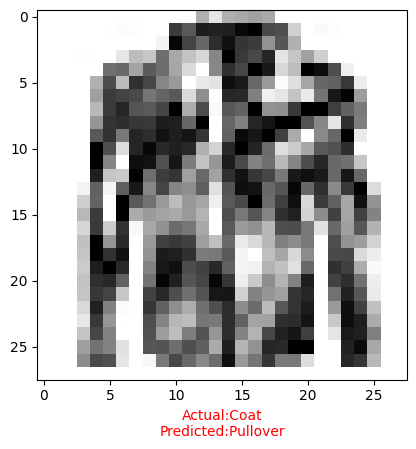

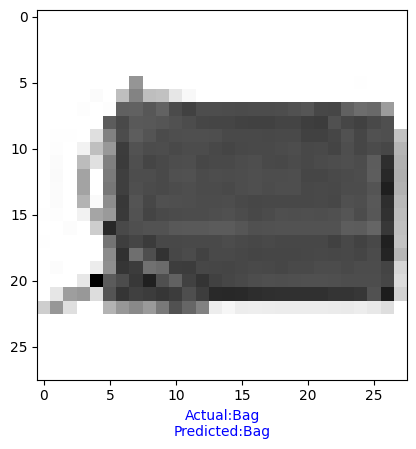

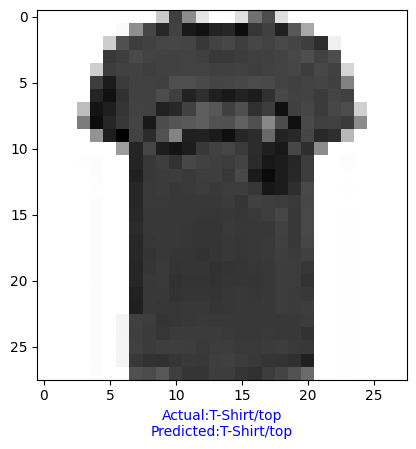

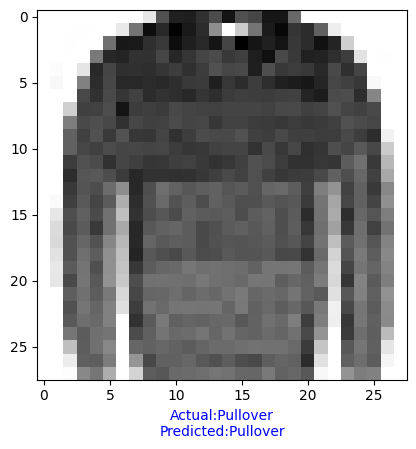

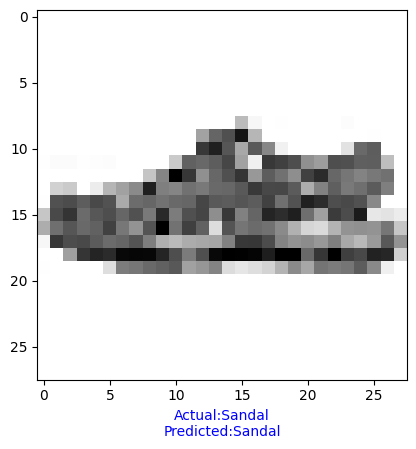

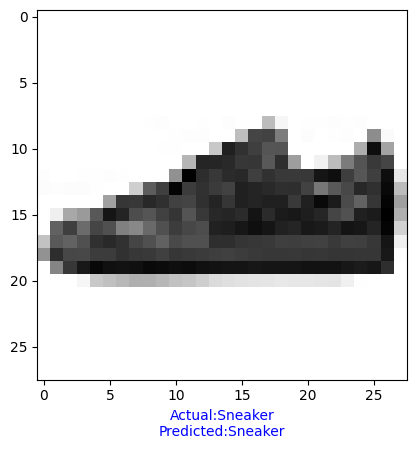

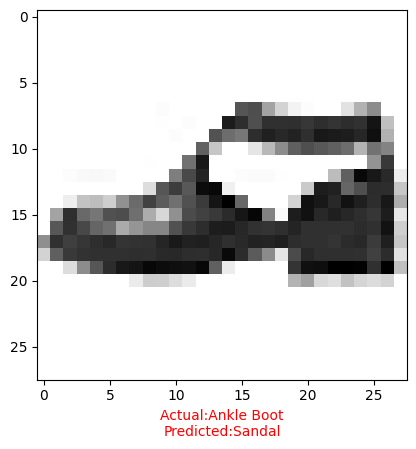

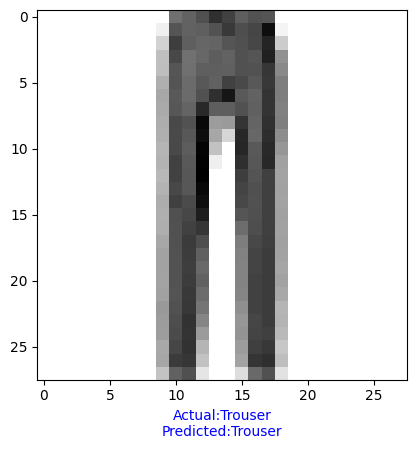

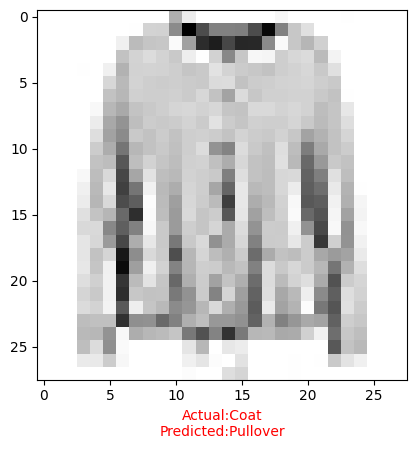

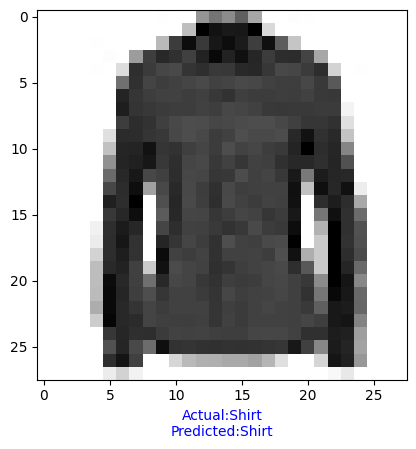

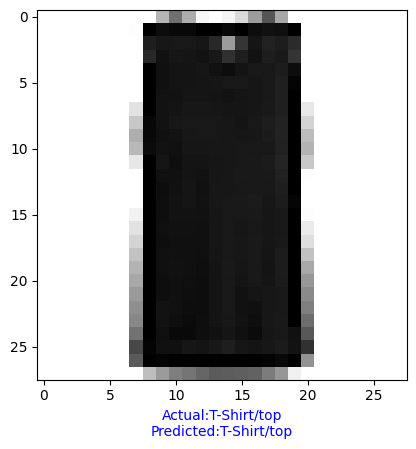

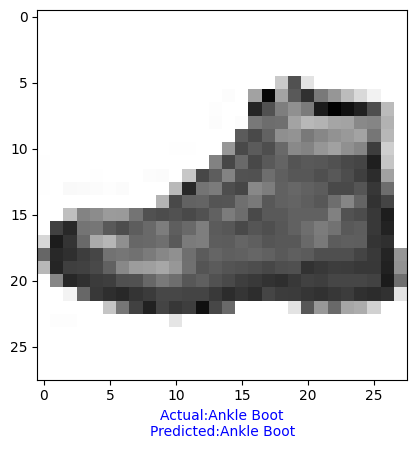

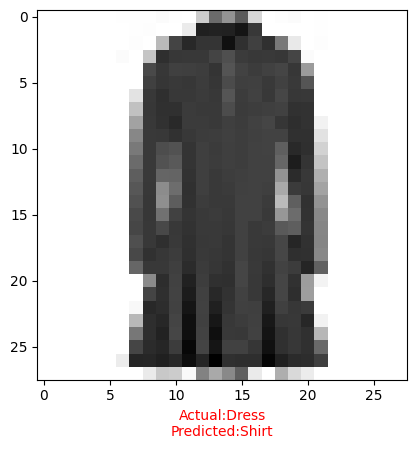

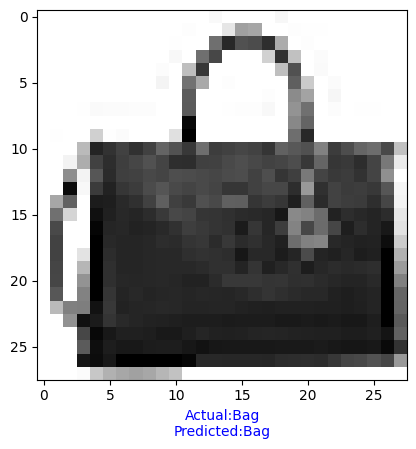

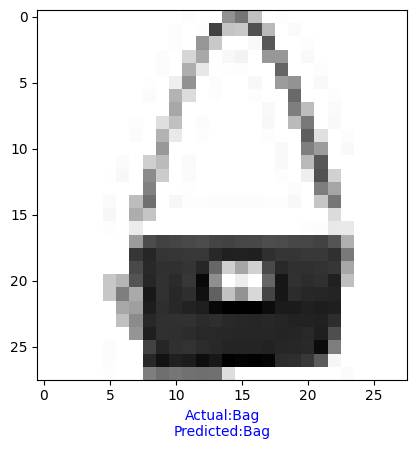

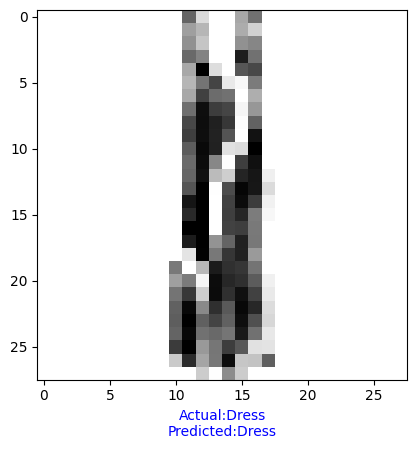

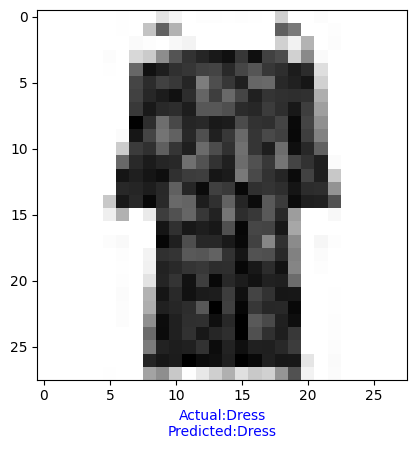

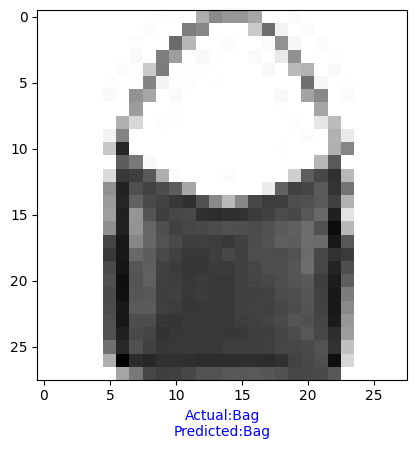

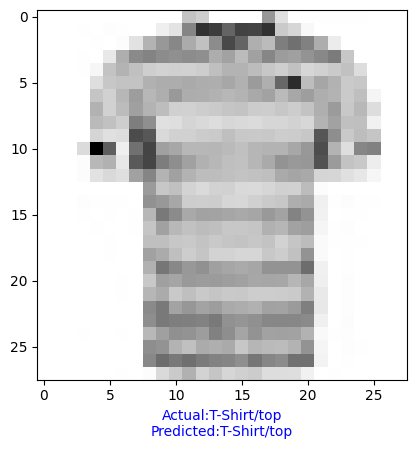

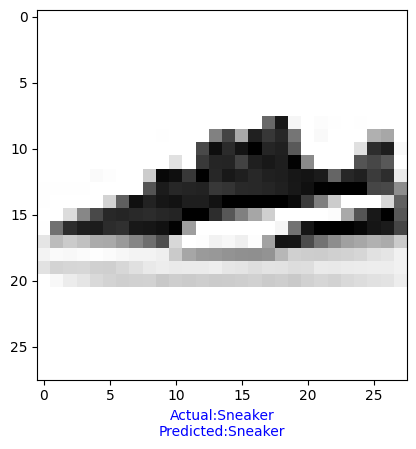

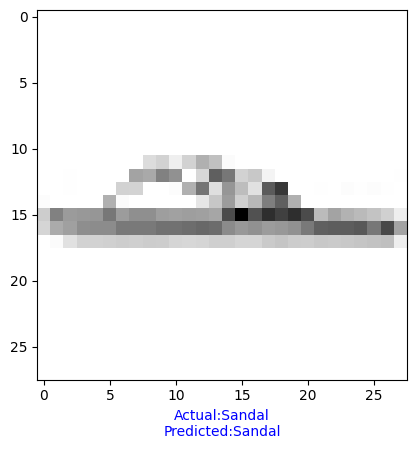

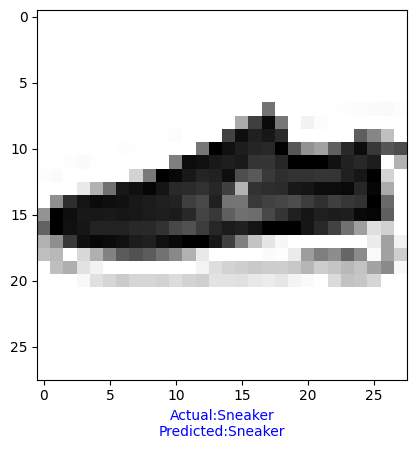

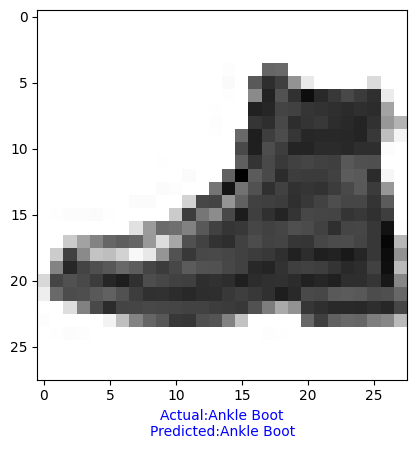

In [60]:
nrows = 4
ncols = 10
t = 1
plt.figure(figsize=(10,6))
for i in range(1,nrows*ncols):
  plt.imshow(x_test[i],cmap='binary',interpolation = 'nearest')
  actual_class = class_names[y_test[i]]
  pred_class = class_names[pred_label[i]]
  colr = 'blue' if actual_class == pred_class else 'red'
  plt.xlabel(f'Actual:{actual_class}\nPredicted:{pred_class}',color = colr)
  plt.show()

In [61]:
from sklearn.metrics import classification_report,confusion_matrix

In [62]:
print(classification_report(y_test,pred_label))

              precision    recall  f1-score   support

           0       0.87      0.79      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.79      0.79      1000
           3       0.89      0.89      0.89      1000
           4       0.81      0.80      0.81      1000
           5       0.98      0.97      0.97      1000
           6       0.64      0.75      0.69      1000
           7       0.94      0.96      0.95      1000
           8       0.99      0.95      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [63]:
class_names[6]

'Shirt'

([<matplotlib.axis.YTick at 0x7d1054d13080>,
 [Text(0, 0, 'T-Shirt/top'),
  Text(0, 1, 'Trouser'),
  Text(0, 2, 'Pullover'),
  Text(0, 3, 'Dress'),
  Text(0, 4, 'Coat'),
  Text(0, 5, 'Sandal'),
  Text(0, 6, 'Shirt'),
  Text(0, 7, 'Sneaker'),
  Text(0, 8, 'Bag'),
  Text(0, 9, 'Ankle Boot')])

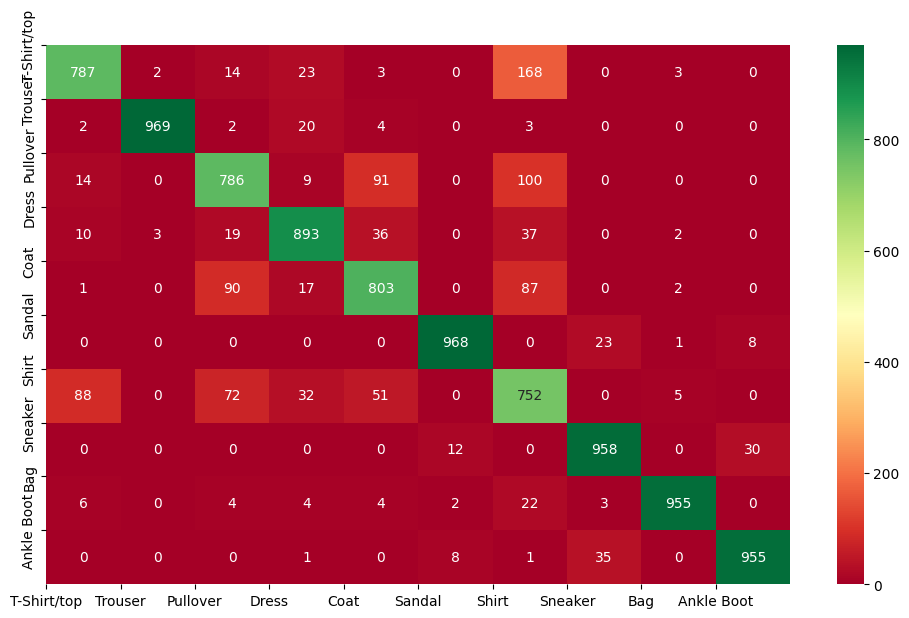

In [67]:
plt.figure(figsize = (12,7))
sns.heatmap(confusion_matrix(y_test,pred_label),annot = True,cmap = 'RdYlGn',fmt = 'd')
plt.xticks(range(10),class_names)
plt.yticks(range(10),class_names)